In [1]:
import pandas as pd

# Load the ADANIPORTS.csv file
df = pd.read_csv('feature_engineered_stock_data.csv')



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2449 entries, 0 to 2448
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                2449 non-null   object 
 1   Symbol              2449 non-null   object 
 2   Series              2449 non-null   object 
 3   Prev Close          2449 non-null   float64
 4   Open                2449 non-null   float64
 5   High                2449 non-null   float64
 6   Low                 2449 non-null   float64
 7   Last                2449 non-null   float64
 8   Close               2449 non-null   float64
 9   VWAP                2449 non-null   float64
 10  Volume              2449 non-null   int64  
 11  Turnover            2449 non-null   float64
 12  Trades              2449 non-null   float64
 13  Deliverable Volume  2449 non-null   int64  
 14  %Deliverble         2449 non-null   float64
 15  future_return_7d    2449 non-null   float64
 16  target

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and day
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['weekday_num'] = df['Date'].dt.weekday

In [10]:
df = df.dropna().reset_index(drop=True)


In [12]:
df.columns

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble', 'future_return_7d', 'target_class', 'return_1d',
       'return_5d', 'rsi_14', 'roc_10', 'cci_20', 'ema_12', 'ema_26', 'macd',
       'signal', 'macd_hist', 'atr_14', 'bb_high', 'bb_low', 'bb_width', 'obv',
       'mfi', 'roll_mean_5', 'roll_std_5', 'roll_mean_20', 'roll_std_20',
       'return_lag_1', 'return_lag_3', 'return_lag_5', 'adx', 'stoch_k',
       'stoch_d', 'williams_r', 'donchian_h', 'donchian_l', 'vol_sma_20',
       'vol_ratio', 'vwap_dev', 'month', 'day', 'weekday_num'],
      dtype='object')

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier

In [27]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [45]:
# Drop non-numeric or non-useful columns
X = df.drop(columns=['Date', 'Symbol', 'Series', 'future_return_7d', 'target_class'])
y = df['target_class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001962 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11251
[LightGBM] [Info] Number of data points in the train set: 1944, number of used features: 47
[LightGBM] [Info] Start training from score -3.282044
[LightGBM] [Info] Start training from score -1.251735
[LightGBM] [Info] Start training from score -1.271717
[LightGBM] [Info] Start training from score -1.084819
[LightGBM] [Info] Start training from score -2.845115
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [46]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.24      0.46      0.31       118
           2       0.36      0.30      0.33       162
           3       0.34      0.28      0.31       144
           4       0.00      0.00      0.00        46

    accuracy                           0.30       486
   macro avg       0.19      0.21      0.19       486
weighted avg       0.28      0.30      0.28       486



In [48]:
feature_names = X.columns

In [50]:
feature_names

Index(['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume',
       'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble', 'return_1d',
       'return_5d', 'rsi_14', 'roc_10', 'cci_20', 'ema_12', 'ema_26', 'macd',
       'signal', 'macd_hist', 'atr_14', 'bb_high', 'bb_low', 'bb_width', 'obv',
       'mfi', 'roll_mean_5', 'roll_std_5', 'roll_mean_20', 'roll_std_20',
       'return_lag_1', 'return_lag_3', 'return_lag_5', 'adx', 'stoch_k',
       'stoch_d', 'williams_r', 'donchian_h', 'donchian_l', 'vol_sma_20',
       'vol_ratio', 'vwap_dev', 'month', 'day', 'weekday_num'],
      dtype='object')

In [49]:
# Get feature names and importance values (using scikit-learn API)
importance_values = model.feature_importances_
feature_names_list = feature_names

# Create and sort a pandas DataFrame
importance_df = pd.DataFrame({'Feature': feature_names_list, 'Importance': importance_values})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print the result
print("--- Feature Importance (Split) ---")
print(importance_df)


--- Feature Importance (Split) ---
               Feature  Importance
41          vol_sma_20        2273
35                 adx        2270
20              signal        1714
26                 obv        1607
25            bb_width        1593
12           return_1d        1575
29          roll_std_5        1565
33        return_lag_3        1560
27                 mfi        1559
22              atr_14        1505
31         roll_std_20        1501
45                 day        1420
32        return_lag_1        1417
21           macd_hist        1410
34        return_lag_5        1404
13           return_5d        1338
11         %Deliverble        1327
43            vwap_dev        1308
19                macd        1263
15              roc_10        1240
16              cci_20        1218
42           vol_ratio        1182
9               Trades        1144
44               month        1141
36             stoch_k        1027
14              rsi_14        1004
37             stoch

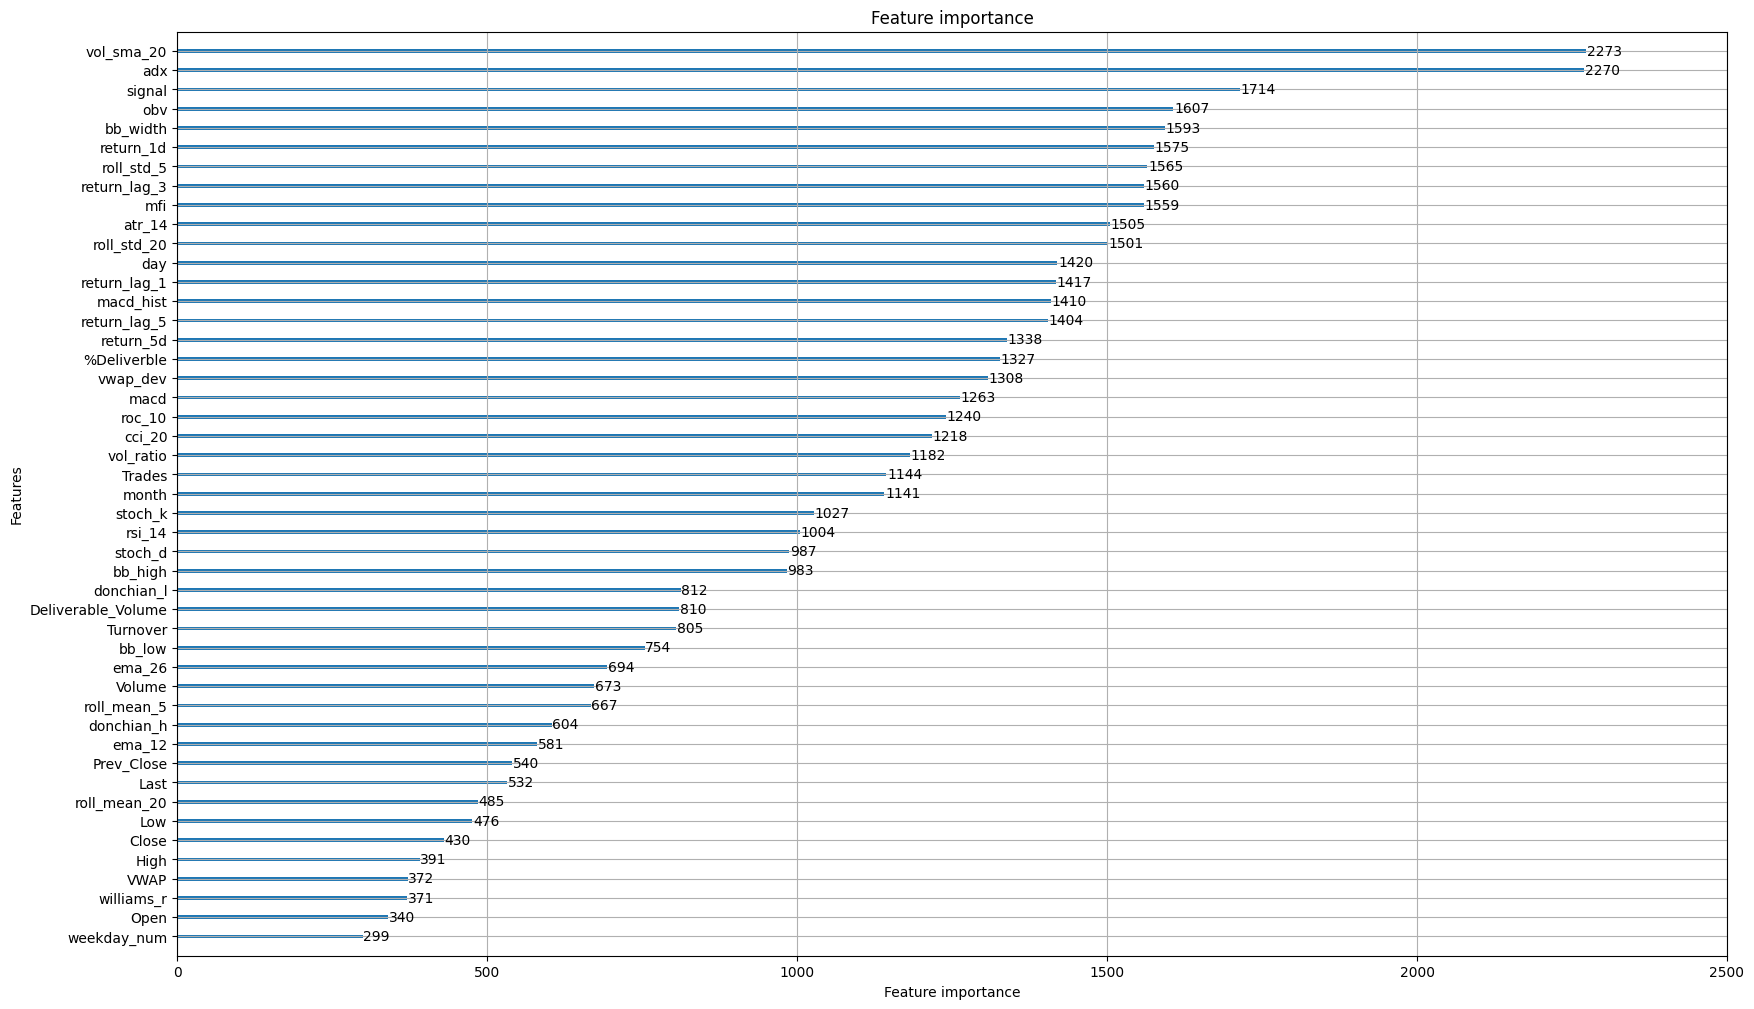

In [47]:
import matplotlib.pyplot as plt
import lightgbm as lgb

lgb.plot_importance(model, figsize=(20,12))
plt.show()


In [ ]:
lgb.importance

In [41]:
xmodel = xgb.XGBClassifier(
    objective='multi:softmax',     # for classification
    num_class=5,                   # since you have 5 classes
    learning_rate=0.05,
    max_depth=6,
    n_estimators=400,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xmodel.fit(X_train, y_train)


C:\Users\Dhile\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [19:09:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None, num_class=5, ...)

In [42]:
y_pred = xmodel.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.23      0.47      0.31       118
           2       0.38      0.39      0.39       162
           3       0.45      0.24      0.32       144
           4       1.00      0.02      0.04        46

    accuracy                           0.32       486
   macro avg       0.41      0.23      0.21       486
weighted avg       0.41      0.32      0.30       486

Confusion Matrix:
 [[ 0  9  7  0  0]
 [ 2 56 47 13  0]
 [ 1 76 63 22  0]
 [ 0 71 38 35  0]
 [ 0 27 10  8  1]]


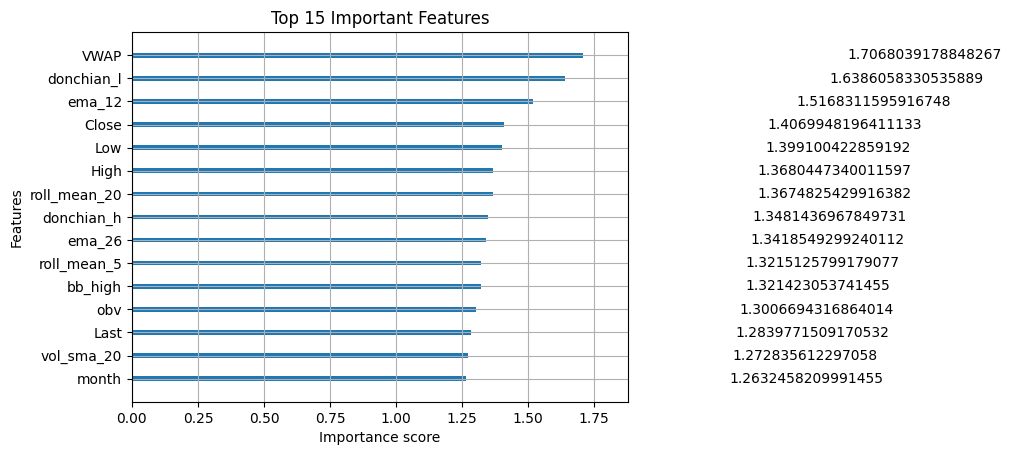

In [43]:
import matplotlib.pyplot as plt
xgb.plot_importance(xmodel, max_num_features=15, importance_type='gain')
plt.title("Top 15 Important Features")
plt.show()
